# 1 Likelihood Based Analysis of the 21-cm Power Spectrum
## a) PCA

In [112]:
import numpy as np  
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import optuna
import torch
from torch import nn, optim
import tqdm
import copy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Import simulation data
data_dir = Path("simulations")
files = sorted(data_dir.glob("*.npz"))

# Define test/train/validation split
num_files = len(files)
train_files = files[:int(0.8 * num_files)]
val_files = files[int(0.8 * num_files):int(0.9 * num_files)]
test_files = files[int(0.9 * num_files):]

# Write 
train_simulations = []
test_simulations = []
val_simulations = []

for f in train_files:
    with np.load(f, allow_pickle=True) as d:
        train_simulations.append(dict(d))

for f in val_files:
    with np.load(f, allow_pickle=True) as d:
        val_simulations.append(dict(d))

for f in test_files:
    with np.load(f, allow_pickle=True) as d:
        test_simulations.append(dict(d))

# Unpack
def unpack_simulations(simulations):
    params_list = []
    power_list  = []
    k_list = []
    for sim in simulations:
        astro = sim['astro_params'].item()
        cosmo = sim['cosmo_params'].item()
        params_list.append([astro['L40_xray'], astro['fesc10'],
                            astro['epsstar'],  cosmo['h_fid']])
        power_list.append(sim['power'])
        k_list.append(sim['k'])
    return np.array(params_list), np.array(power_list), np.array(k_list)

raw_params_train, power_train, k_train = unpack_simulations(train_simulations)
raw_params_val,   power_val,   k_val   = unpack_simulations(val_simulations)
raw_params_test,  power_test,  k_test  = unpack_simulations(test_simulations)

# power_train = np.log(raw_power_train)
# power_test = np.log(raw_power_test)
# power_val = np.log(raw_power_val)


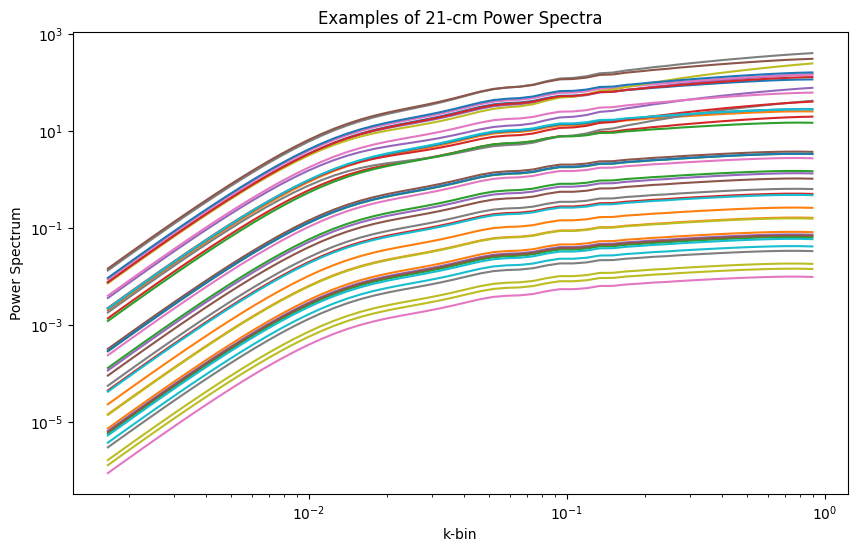

In [3]:
# Plot the power spectra examples
plt.figure(figsize=(10, 6))
for i in  range(0, 8000, 200):
    plt.loglog(k_train[i], power_train[i], label=f'Sim {i+1}')
plt.xlabel('k-bin')
plt.ylabel('Power Spectrum')
plt.title('Examples of 21-cm Power Spectra')
# plt.legend()
plt.show()

- We must normalise the training parameters as they can have different scales with respect to one another. We don't want to bias the trained NN based on the various input scales so we can scale them using a StandardScaler, which brings the mean to 0 and variance to 1.
- Each power spectrum mode has a different scale. For PCA, we want to find meaningful variations, not just the largest magnitude variations, which can be a result of different component scales. A component can have little relative variance in its axis but a huge absolute variance because of scale. As such, we normalise our power spectra as well.
- Since the power spectra vary across several orders of magnitude, it is prudent to work with the logarithm.

In [4]:
# Normalise (Scale) datasets
params_scaler = StandardScaler().fit(raw_params_train)

# Apply the same transformation to all datasets
params_train = params_scaler.transform(raw_params_train)
params_val   = params_scaler.transform(raw_params_val)
params_test  = params_scaler.transform(raw_params_test)

- Now we apply PCA on this data

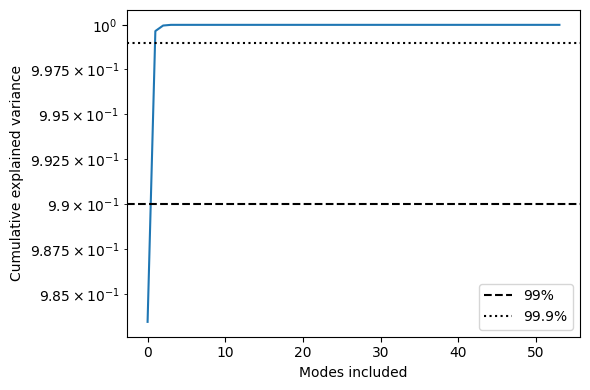

In [ ]:
# Compute the covairance matrix of the power spectra
power_cov = np.cov(power_train, rowvar=False)
evals, evecs = np.linalg.eig(power_cov) # evecs are columns


# Sort from largest to smallest eigenvalues
args = np.argsort(evals)[::-1] # Decreasing size has to flip
evals = np.real(evals[args])
evecs = evecs[:, args]



# Look at explained variance plot
exp_var = evals / np.sum(evals)
cum_exp_var = np.cumsum(exp_var)


# Plot the explained variance
plt.figure(figsize=(6,4))
plt.yscale('log')
plt.plot(cum_exp_var)
plt.axhline(0.99, ls='--', c='k', label='99%')
plt.axhline(0.999, ls=':', c='k', label='99.9%')
plt.xlabel("Modes included")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
thresholds = [0.99, 0.999, 0.9999]
for threshold in thresholds:
    n = np.searchsorted(cum_exp_var, threshold) + 1
    print(f"{100 * threshold:.1f}% threshold explained by first {n} components")

99.0% threshold explained by first 2 components
99.9% threshold explained by first 2 components
100.0% threshold explained by first 3 components


- This tells us that the first three eigenvectors are all we need to describe the entire variance of this data. It will be valid to compress the training data down using just the first three eigenvectors. 
- However, the explained variance does not correspond directly to emulator accuracy. There are a few more factors to consider:
    - The emulated likelihood may depend on some rare features which only appear in the extremes of some parameter. Because the feature is rare, this leaves a very low variance footprint in the PCA.
    - The emulated likelihood may depend on some small scale feature which looks very small in absolute variance terms.
    - The training set may not be completely representative. Some features appearing in the validation set might not appear here.
- It would not cost too much more to perform the analysis with a few more components for safety.

In [ ]:
n_comp = 6

# Use PCA from sklearn for stability

pca = PCA(n_components=n_comp)
pca.fit(power_train)

eig_vals = pca.explained_variance_
W = pca.components_.T

# Project the spectra onto the top n_comp components
projected_coeffs_train = np.real(np.dot(power_train, W)) # bc W are columns we take all rows
projected_coeffs_test = np.real(np.dot(power_test, W))
projected_coeffs_val = np.real(np.dot(power_val, W))

# Check reconstructed spectra
def check_reconstructed_spectra(power = power_train,projected_coeffs = projected_coeffs_train,idx=0, plot = False):
    reconstructed = np.dot(projected_coeffs[idx], W.T)
    
    frac_residual = 100 * np.abs(power[idx] - reconstructed) / np.abs(power[idx])

    if plot == True:
        fig, ax = plt.subplots(1, 3, figsize=(10, 3))
        
        for i in range(n_comp):
            ax[0].semilogx(k_train[i], projected_coeffs[idx, i] * W[:, i], label=f'E-vec {i+1}')
        ax[0].set_xlabel(r'$k$  [Mpc$^{-1}$]')
        ax[0].set_ylabel('Contribution')
        ax[0].set_title('PCA components')
        ax[0].legend(fontsize=7)
        ax[1].loglog(k_train[0], power[idx],   label='Original')
        ax[1].loglog(k_train[0], reconstructed, label=f'PCA with {n_comp} components)', ls='--')
        ax[1].set_xlabel(r'$k$  [Mpc$^{-1}$]')
        ax[1].set_ylabel(r'$\Delta^2(k)$  [mK$^2$]')
        ax[1].set_title('Reconstructed spectrum')
        ax[1].legend()
        
        ax[2].semilogx(k_train[0], frac_residual)
        ax[2].set_xlabel(r'$k$  [Mpc$^{-1}$]')
        ax[2].set_ylabel('Fractional residual (%)')
        ax[2].set_title('Residual')
        
        plt.tight_layout()
        plt.show()
    mean_frac_residual = frac_residual.mean()
    return mean_frac_residual

c:\Users\Joey\Desktop\Cambridge\Work\A1\A1CW\Machine-Learning-Enhanced-Inference-of-the-21-cm-Power-Spectrum-at-Cosmic-Dawn\VenvA1Cw\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Joey\Desktop\Cambridge\Work\A1\A1CW\Machine-Learning-Enhanced-Inference-of-the-21-cm-Power-Spectrum-at-Cosmic-Dawn\VenvA1Cw\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


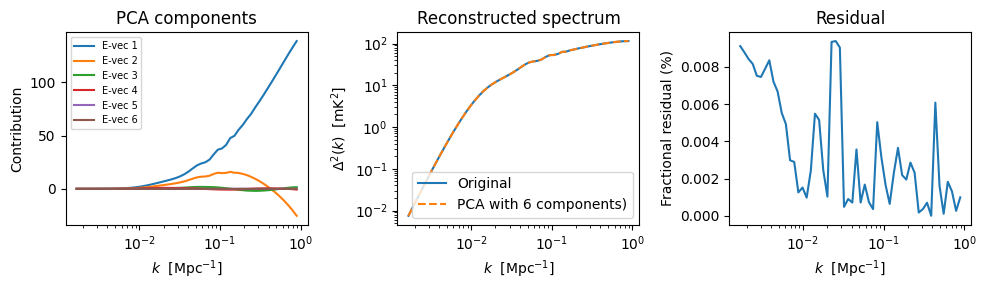

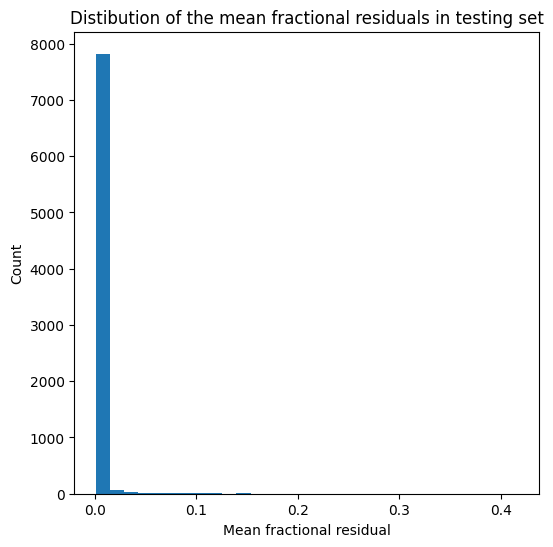

In [8]:
_ = check_reconstructed_spectra(plot = True)
frac_residuals= []

for j in range(0,len(projected_coeffs_train)):
    frac_residual = check_reconstructed_spectra(idx=j)
    frac_residuals.append(frac_residual)

# Plot histogram of fractional residuals
plt.figure(figsize=(6,6))
plt.hist(frac_residuals, bins= 30)
plt.title("Distibution of the mean fractional residuals in testing set")
plt.xlabel("Mean fractional residual")
plt.ylabel("Count")
plt.show()

# b) NN 



In [ ]:
# Exmine our weight ranges and plot them

weight_ranges = []
for i in range(0,6):
    feature_weights = np.real(projected_coeffs_train[:,i])
    weight_max = max(feature_weights)
    weight_min = min(feature_weights)
    weight_mean = feature_weights.mean()
    weight_ranges.append([weight_max, weight_min, weight_mean])


for idx, weight_range in enumerate(weight_ranges):
    print(f"Feature {idx} has range {weight_range[1]:.3e} to {weight_range[0]:.3e} with mean {weight_range[2]:.3e}")



Feature 0 has range 2.679e-02 to 1.856e+03 with mean 1.961e+02
Feature 1 has range -2.475e+02 to 1.105e+02 with mean 2.024e+00
Feature 2 has range -5.831e+01 to 1.236e+01 with mean -1.854e+00
Feature 3 has range -1.451e+01 to 5.563e+00 with mean 9.020e-01
Feature 4 has range -6.091e-01 to 3.335e-01 with mean -4.902e-03
Feature 5 has range -3.213e-01 to 7.160e-02 with mean -1.341e-02


- The ranges of the each PCA component's weights across the sample projections often spans several orders of magnitude and the mean weights also span several orders of magnitude between the features.
- We should normalise each one to to have zero mean and unit variance for best NN performance.

In [ ]:
weight_scaler =  StandardScaler().fit(projected_coeffs_train) # Normalise across the weight features on the train 

# Now scale the test and valid set -> nomenclature for the weights will be y
y_test = weight_scaler.transform(projected_coeffs_test)
y_val = weight_scaler.transform(projected_coeffs_val)
y_train = weight_scaler.transform(projected_coeffs_train)
  

In [24]:
x_train = torch.tensor(params_train, dtype=torch.float32)
x_val   = torch.tensor(params_val, dtype=torch.float32)
x_test  = torch.tensor(params_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val   = torch.tensor(y_val, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)



In [12]:
# Exmine our new weight ranges
weight_ranges = []
for i in range(0,6):
    feature_weights = np.real(y_train[:,i])
    weight_max = max(feature_weights)
    weight_min = min(feature_weights)
    weight_mean = feature_weights.mean()
    weight_ranges.append([weight_max, weight_min, weight_mean])
for idx, weight_range in enumerate(weight_ranges):
    print(f"Transformed feature {idx} has range {weight_range[1]:.3e} to {weight_range[0]:.3e} with mean {weight_range[2]:.3e}")



Transformed feature 0 has range -5.784e-01 to 4.897e+00 with mean -7.286e-16
Transformed feature 1 has range -5.740e+00 to 2.495e+00 with mean 1.510e-17
Transformed feature 2 has range -9.381e+00 to 2.362e+00 with mean 6.486e-17
Transformed feature 3 has range -7.303e+00 to 2.209e+00 with mean -1.777e-17
Transformed feature 4 has range -7.623e+00 to 4.270e+00 with mean 1.111e-18
Transformed feature 5 has range -9.311e+00 to 2.571e+00 with mean -9.418e-16


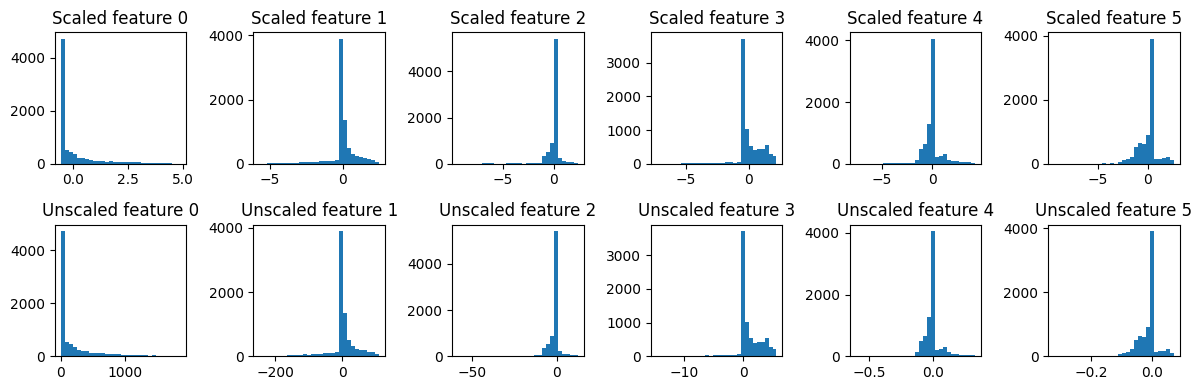

In [ ]:
# fig, ax = plt.subplots(2, 6, figsize=(12, 4))

# for i in range(6):
#     scaled_weights = np.real(y_train[:, i])
#     unscaled_weights = np.real(projected_coeffs_train[:, i])

#     ax[0, i].hist(scaled_weights, bins=30)
#     ax[1, i].hist(unscaled_weights, bins=30)

#     ax[0, i].set_title(f"Scaled feature {i}")
#     ax[1, i].set_title(f"Unscaled feature {i}")

# plt.tight_layout()
# plt.show()

fig, ax = plt.subplots(6, 2, figsize=(10, 18))

for i in range(6):
    original = np.real(projected_coeffs_train[:, i])
    scaled = np.real(y_train[:, i])

    ax[i, 0].hist(original, bins=30)
    ax[i, 0].set_title(f"Feature {i} original")

    ax[i, 1].hist(scaled, bins=30)
    ax[i, 1].set_title(f"Feature {i} scaled")

plt.tight_layout()
plt.show()

- This looks good. Now we train the NN. 
- We will train a fully connected model. 
- To determine the depth, width, and LR we will use for the model, I will run an optuna optimisation.

In [17]:
class Emulator(nn.Module):
    def __init__(self, input_dim = 4, output_dim = n_comp, hidden_dim=64, num_layers=4):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, hidden_dim)) # Defines the input
        for _ in range(num_layers):
            self.layers.append(nn.Linear(hidden_dim,hidden_dim))
        self.layers.append(nn.Linear(hidden_dim, output_dim))

    def forward(self, x):
        for layer in self.layers[:-1]: # [:-1] bc we do not want to relu the last laye
            x = torch.relu(layer(x))
        x = self.layers[-1](x)
        return x


In [ ]:
# def train_model(model, x_train, y_train, x_val, y_val, optimiser, epochs=1000, 
#                 batch_size=128, verbose=True, plot=False, savefig=None, trial=None):
#     torch.manual_seed(1701)
#     train_losses = []
#     valid_losses = []
#     best_valid_loss = float("inf")
#     best_epoch = -1
#     best_state_dict = None

#     for epoch in range(epochs):
#         model.train()
#         total_train_loss = 0.0
#         num_batches = 0

#         # shuffling
#         perm = torch.randperm(len(x_train))
#         x_shuffled = x_train[perm]
#         y_shuffled = y_train[perm]

#         # go through this epoch's batches
#         for batch in range(0, len(x_shuffled), batch_size):
#             x_batch = x_shuffled[batch:batch + batch_size]
#             y_batch = y_shuffled[batch:batch + batch_size]

#             optimiser.zero_grad()
#             loss = nn.functional.mse_loss(model(x_batch), y_batch)
            
#             loss.backward()
#             optimiser.step()

#             total_train_loss += loss.item()
#             num_batches += 1

#         avg_train_loss = total_train_loss / num_batches
#         train_losses.append(avg_train_loss)

#         model.eval()
#         with torch.no_grad():
#             valid_loss = nn.functional.mse_loss(model(x_val), y_val)
        
#         valid_losses.append(valid_loss)

#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss
#             best_train_loss = avg_train_loss
#             best_epoch = epoch
#             best_state_dict = copy.deepcopy(model.state_dict())
        
#         if trial is not None:
#             trial.report(valid_loss, step=epoch)
#             if trial.should_prune():
#                 raise optuna.TrialPruned()
            
#         if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
#             print(
#                 f"Epoch {epoch+1}/{epochs}, "
#                 f"Train Loss: {avg_train_loss:.4f}, "
#                 f"Valid Loss: {valid_loss:.4f}, "
#                 f"LR: {optimiser.param_groups[0]['lr']:.2e}"
#             )
#     if plot:
#         plt.plot(train_losses, label="Train Loss")
#         plt.plot(valid_losses, label="Validation Loss")
#         plt.xlabel("Epoch")
#         plt.ylabel("MSE")
#         plt.title("Training and Validation Loss")
#         plt.legend()
#         if savefig is not None:
#             plt.savefig(savefig)
#         plt.show()

#     if best_state_dict is not None:
#         model.load_state_dict(best_state_dict)


#     return best_valid_loss, best_train_loss, best_epoch, model # model is best model

    



# def objective(trial):
#     num_layers = trial.suggest_categorical("num_layers", [4,6])
#     hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64])
#     lr = trial.suggest_float("lr", 5e-5, 1e-2, log=True)
#     weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True) # introduce a it of weight decay for stability
    
#     torch.manual_seed(1701)

#     model = Emulator(hidden_dim=hidden_dim, num_layers=num_layers)

#     optimiser = optim.Adam(
#         model.parameters(),
#         lr = lr,
#         weight_decay = weight_decay
#     )

#     best_valid_loss, best_train_loss, best_epoch, best_model = train_model(
#         model, x_train, y_train, x_val, y_val, optimiser, epochs=200, 
#         verbose=False, trial=trial
#     )

#     trial.set_user_attr("best_epoch", best_epoch)


#     return best_valid_loss

In [ ]:
import copy

def train_model(model, x_train, y_train, x_val, y_val, optimiser, epochs=1000,
                batch_size=512, verbose=True, plot=False, savefig=None,
                trial=None, patience=100):
    torch.manual_seed(1701)

    train_losses = []
    valid_losses = []

    best_valid_loss = float("inf")
    best_train_loss = None
    best_epoch = -1
    best_state_dict = None

    epochs_since_improvement = 0

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        num_batches = 0

        perm = torch.randperm(len(x_train))
        x_shuffled = x_train[perm]
        y_shuffled = y_train[perm]

        for batch in range(0, len(x_shuffled), batch_size):
            x_batch = x_shuffled[batch:batch + batch_size]
            y_batch = y_shuffled[batch:batch + batch_size]

            optimiser.zero_grad()
            loss = nn.functional.mse_loss(model(x_batch), y_batch)
            loss.backward()
            optimiser.step()

            total_train_loss += loss.item()
            num_batches += 1

        avg_train_loss = total_train_loss / num_batches
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            valid_loss = nn.functional.mse_loss(model(x_val), y_val).item()

        valid_losses.append(valid_loss)

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_train_loss = avg_train_loss
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        if trial is not None:
            trial.report(valid_loss, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
            print(
                f"Epoch {epoch+1}/{epochs}, "
                f"Train Loss: {avg_train_loss:.4f}, "
                f"Valid Loss: {valid_loss:.4f}, "
                f"LR: {optimiser.param_groups[0]['lr']:.2e}"
            )

        if epochs_since_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}. Best epoch was {best_epoch+1}.")
            break

    if plot:
        plt.plot(train_losses, label="Train Loss")
        plt.plot(valid_losses, label="Validation Loss")
        plt.yscale("log")
        plt.xlabel("Epoch")
        plt.ylabel("MSE")
        plt.title("Training and Validation Loss")
        plt.legend()
        if savefig is not None:
            plt.savefig(savefig)
        plt.show()

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return best_valid_loss, best_train_loss, best_epoch, model


def objective(trial):
    num_layers = trial.suggest_categorical("num_layers", [3,4,5,6])
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128])
    lr = trial.suggest_float("lr", 1e-5, 1e-4, log=True)
    # weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True)

    torch.manual_seed(1701)

    model = Emulator(hidden_dim=hidden_dim, num_layers=num_layers)

    optimiser = optim.Adam(
        model.parameters(),
        lr=lr,
        # weight_decay=weight_decay
    )

    best_valid_loss, best_train_loss, best_epoch, best_model = train_model(
        model, x_train, y_train, x_val, y_val, optimiser,
        epochs=1000, verbose=False, trial=trial, patience=100
    )

    trial.set_user_attr("best_epoch", best_epoch)
    trial.set_user_attr("best_train_loss", best_train_loss)

    return best_valid_loss

In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

[I 2026-03-25 17:18:39,771] A new study created in memory with name: no-name-cdfe0c93-8817-4783-b261-7ea60342cbea
[I 2026-03-25 17:18:57,843] Trial 0 finished with value: 0.0022433127742260695 and parameters: {'num_layers': 4, 'hidden_dim': 128, 'lr': 6.0498750079041145e-05}. Best is trial 0 with value: 0.0022433127742260695.
[I 2026-03-25 17:19:08,287] Trial 1 finished with value: 0.5589834451675415 and parameters: {'num_layers': 4, 'hidden_dim': 32, 'lr': 1.657725468511156e-05}. Best is trial 0 with value: 0.0022433127742260695.
[I 2026-03-25 17:19:21,289] Trial 2 finished with value: 0.02602730132639408 and parameters: {'num_layers': 4, 'hidden_dim': 64, 'lr': 2.9120197746691772e-05}. Best is trial 0 with value: 0.0022433127742260695.
[I 2026-03-25 17:19:42,626] Trial 3 finished with value: 0.03352583572268486 and parameters: {'num_layers': 5, 'hidden_dim': 128, 'lr': 1.1155411038392302e-05}. Best is trial 0 with value: 0.0022433127742260695.
[I 2026-03-25 17:19:52,411] Trial 4 fini

In [108]:
print("Best trial:")
print("  value:", study.best_trial.value)
print("  params:", study.best_trial.params)
print("  best_epoch:", study.best_trial.user_attrs["best_epoch"])


Best trial:
  value: 0.0015733856707811356
  params: {'num_layers': 5, 'hidden_dim': 128, 'lr': 9.718374118022918e-05}
  best_epoch: 296


Epoch 1/10000, Train Loss: 1.0014, Valid Loss: 1.0407, LR: 9.72e-05
Epoch 101/10000, Train Loss: 0.0037, Valid Loss: 0.0046, LR: 9.72e-05
Epoch 201/10000, Train Loss: 0.0016, Valid Loss: 0.0024, LR: 9.72e-05
Epoch 301/10000, Train Loss: 0.0012, Valid Loss: 0.0017, LR: 9.72e-05
Epoch 401/10000, Train Loss: 0.0008, Valid Loss: 0.0014, LR: 9.72e-05
Epoch 501/10000, Train Loss: 0.0006, Valid Loss: 0.0011, LR: 9.72e-05
Epoch 601/10000, Train Loss: 0.0006, Valid Loss: 0.0013, LR: 9.72e-05
Epoch 701/10000, Train Loss: 0.0006, Valid Loss: 0.0011, LR: 9.72e-05
Epoch 801/10000, Train Loss: 0.0004, Valid Loss: 0.0008, LR: 9.72e-05
Epoch 901/10000, Train Loss: 0.0004, Valid Loss: 0.0008, LR: 9.72e-05
Epoch 1001/10000, Train Loss: 0.0004, Valid Loss: 0.0009, LR: 9.72e-05
Epoch 1101/10000, Train Loss: 0.0003, Valid Loss: 0.0007, LR: 9.72e-05
Epoch 1201/10000, Train Loss: 0.0003, Valid Loss: 0.0006, LR: 9.72e-05
Epoch 1301/10000, Train Loss: 0.0003, Valid Loss: 0.0006, LR: 9.72e-05
Epoch 1401/10000, 

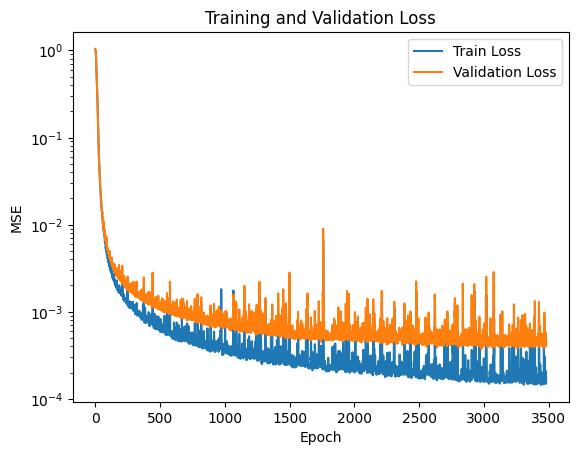

In [109]:
# Retrain best model on train + val and evaluate on test
best_params = study.best_trial.params
torch.manual_seed(1701)

best_model = Emulator(hidden_dim=best_params["hidden_dim"], num_layers=best_params["num_layers"])
best_optimizer = optim.Adam(
        best_model.parameters(),
        lr=best_params["lr"],
    )

        # weight_decay=best_params["weight_decay"],


best_valid_loss, best_train_loss, best_epoch, best_model = train_model(
        best_model, x_train, y_train, x_val, y_val, best_optimizer, epochs=10000, 
        verbose=True, trial=None, plot=True, patience=500
    )


### COMMENT

- Our best model is now stored as the best_model.
- We can now examing best_model's performance on the test set.

The test loss MSE is 4.463e-04 in normalised space


c:\Users\Joey\Desktop\Cambridge\Work\A1\A1CW\Machine-Learning-Enhanced-Inference-of-the-21-cm-Power-Spectrum-at-Cosmic-Dawn\VenvA1Cw\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Joey\Desktop\Cambridge\Work\A1\A1CW\Machine-Learning-Enhanced-Inference-of-the-21-cm-Power-Spectrum-at-Cosmic-Dawn\VenvA1Cw\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


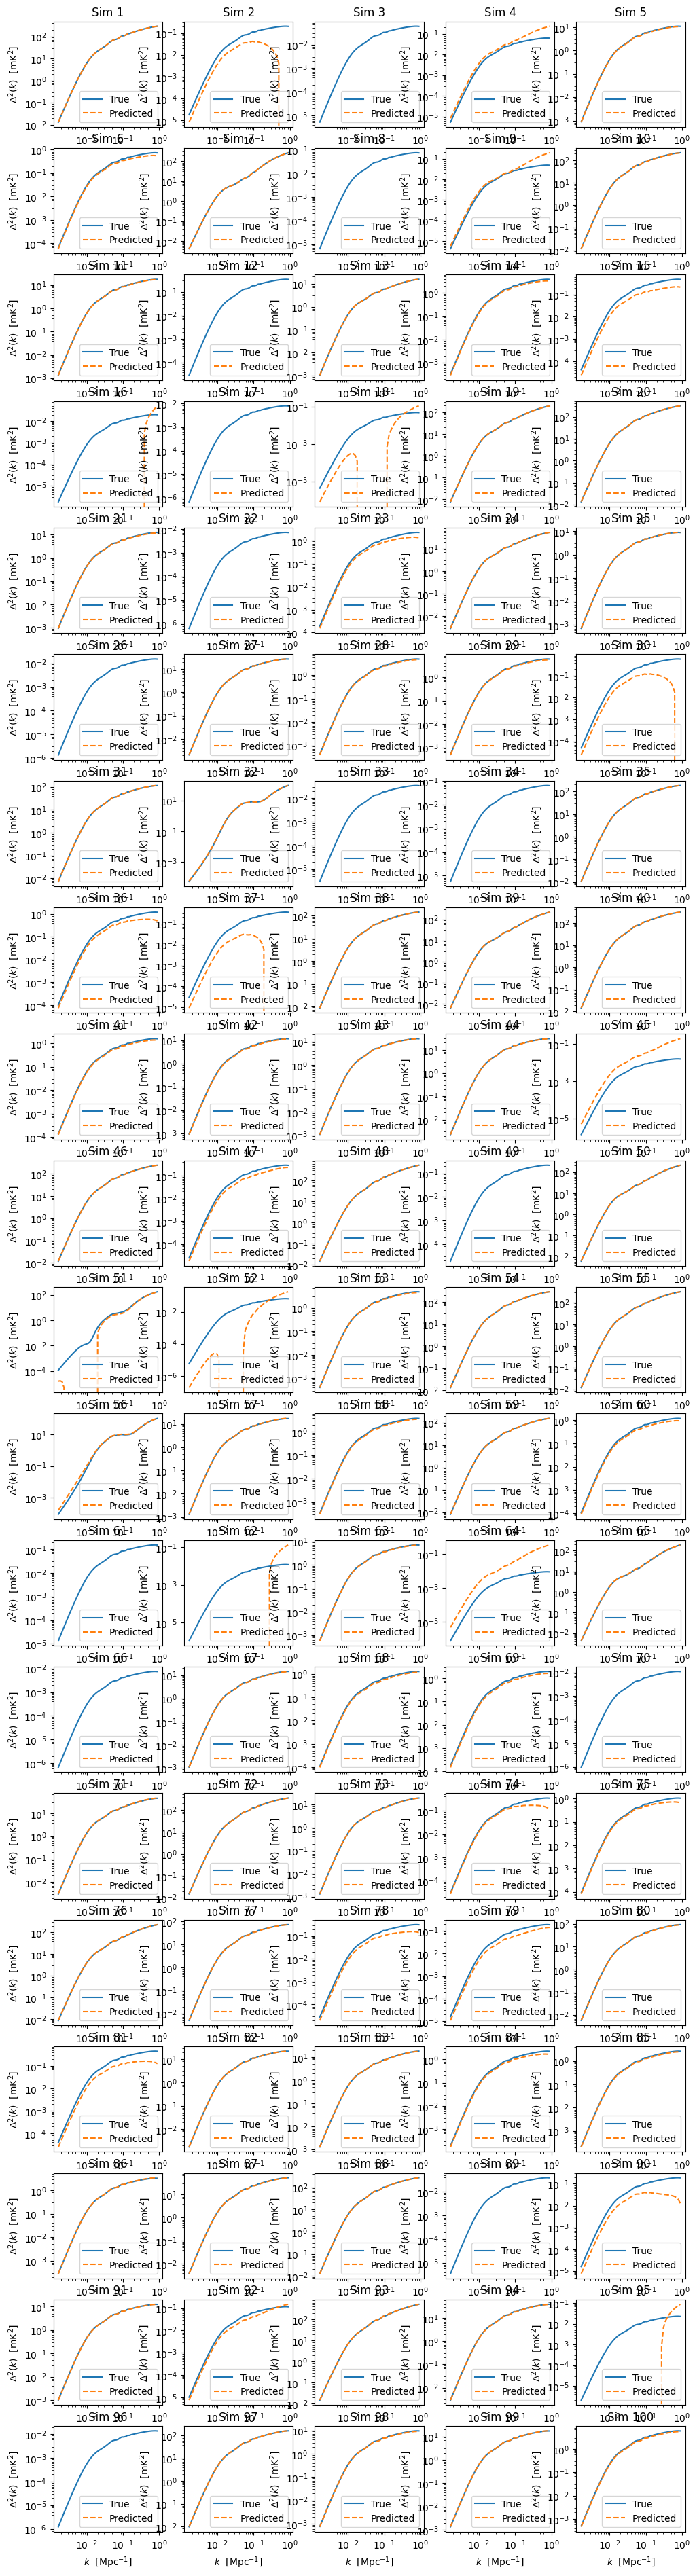

In [110]:
# Make the predictions
unscaled_pred_weights_test = best_model(x_test).detach().numpy()
test_loss = nn.functional.mse_loss(torch.tensor(unscaled_pred_weights_test), y_test).item()
print(f"The test loss MSE is {test_loss:.3e} in normalised space")

# Rescale our predictions
pred_weights_test = weight_scaler.inverse_transform(unscaled_pred_weights_test)
test_pred_spectra =  np.dot(pred_weights_test, evecs[:, :n_comp].T)

# Plot a few as subplots
fig, ax = plt.subplots(20,5, figsize = (12,48))
for i in range(100):
    ax[i//5, i%5].loglog(k_test[i], power_test[i], label='True')
    ax[i//5, i%5].loglog(k_test[i], test_pred_spectra[i], label='Predicted', ls='--')
    ax[i//5, i%5].set_xlabel(r'$k$  [Mpc$^{-1}$]')
    ax[i//5, i%5].set_ylabel(r'$\Delta^2(k)$  [mK$^2$]')
    ax[i//5, i%5].set_title(f'Sim {i+1}')
    ax[i//5, i%5].legend()

- These are mostly pretty good!
- Now we consider the fractional residual error across the test set.


Mean error:       159.072 %
95th percentile:  879.083 %


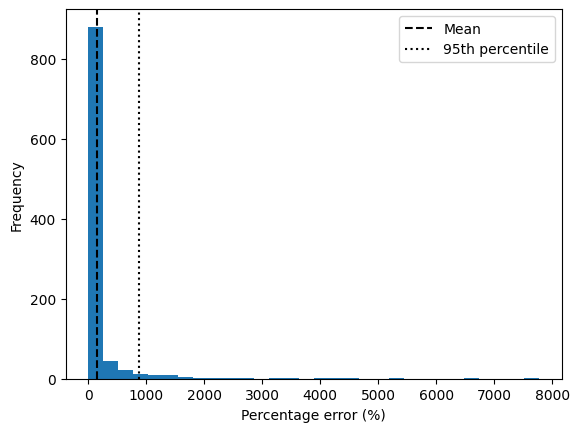

In [111]:
test_frac_residuals = []
mean_test_error = 100 * np.mean(
    np.abs(power_test - test_pred_spectra) / np.abs(power_test),
    axis=1
)

print(f'Mean error:       {np.mean(mean_test_error):.3f} %')
print(f'95th percentile:  {np.quantile(mean_test_error, 0.95):.3f} %')

plt.hist(mean_test_error, bins=30)
plt.axvline(np.mean(mean_test_error),          label='Mean',          ls='--', c='k')
plt.axvline(np.quantile(mean_test_error, 0.95),label='95th percentile', ls=':',  c='k')
plt.xlabel('Percentage error (%)')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('errors.png', dpi=300, bbox_inches='tight')
plt.show()

---------------------------------------

In [15]:
dataset1 = np.load(files[0], allow_pickle=True)
dataset1.files
k = dataset1["k"]
power = dataset1["power"]
astro_params = dataset1["astro_params"]
cosmo_params = dataset1["cosmo_params"]
redshifts = dataset1["redshfit"]
code = dataset1["code"]
code_version = dataset1["code_version"]

for name, value in {
    "k": k,
    "power": power,
    "astro_params": astro_params,
    "cosmo_params": cosmo_params,
    "redshifts": redshifts,
    "code": code,
    "code_version": code_version,
}.items():
    print(f"{name}: {np.shape(value)}")

# print(k)
print(power)
print(np.log(min(power)), np.log(max(power)))
# print(astro_params)
# print(cosmo_params)
# print(redshifts)
# print(code)
# print(code_version)

k: (54,)
power: (54,)
astro_params: ()
cosmo_params: ()
redshifts: ()
code: ()
code_version: ()
[7.47685668e-03 1.17543845e-02 1.84238133e-02 2.87766302e-02
 4.47646190e-02 6.93055195e-02 1.06708847e-01 1.63245637e-01
 2.47878651e-01 3.73112822e-01 5.55905140e-01 8.18373566e-01
 1.18797717e+00 1.69641376e+00 2.37663902e+00 3.25690954e+00
 4.35249707e+00 5.65582583e+00 7.13087339e+00 8.71596303e+00
 1.03440688e+01 1.19720621e+01 1.36169846e+01 1.53657351e+01
 1.73573602e+01 1.97819180e+01 2.28448366e+01 2.66964759e+01
 3.11004660e+01 3.50089825e+01 3.71703915e+01 3.82915299e+01
 4.12093427e+01 4.74106189e+01 5.26737507e+01 5.31096109e+01
 5.61649336e+01 6.30732838e+01 6.40220110e+01 6.90476713e+01
 7.24870554e+01 7.67418995e+01 7.99308894e+01 8.42847893e+01
 8.80104033e+01 9.18137867e+01 9.56606479e+01 9.93856162e+01
 1.02964900e+02 1.06345587e+02 1.09440159e+02 1.12026565e+02
 1.13814238e+02 1.14498132e+02]
-4.895942805268216 4.740558504202362
